In [1]:
## import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Text(0, 0.5, 'Y dataset')

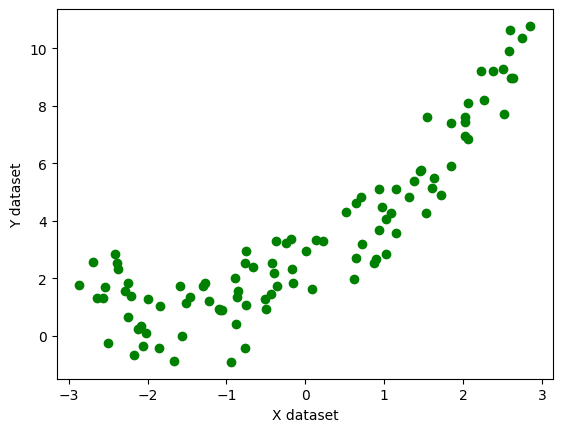

In [21]:
X = 6 * np.random.rand(100 , 1) - 3
y = 0.5 * X**2 + 1.5*X + 2 + np.random.randn(100, 1)
# quadratic equation used - y=0.5x^2+1.5x+2+outliers
plt.scatter(X,y,color='g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')

In [22]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [23]:
## Lets implement Simple Linear Regression
from sklearn.linear_model import LinearRegression
regression_1=LinearRegression()

In [24]:
X_train

array([[ 1.02392235],
       [-1.08028498],
       [-1.26624964],
       [ 0.51112179],
       [-0.35666282],
       [ 2.37252337],
       [ 0.08269093],
       [ 1.08698189],
       [-1.05091169],
       [-0.40043694],
       [-0.76575658],
       [ 0.92770749],
       [-0.16908783],
       [ 2.85059054],
       [-2.50507202],
       [-0.85116556],
       [-2.08030678],
       [ 0.93746123],
       [ 0.13833666],
       [ 2.50414229],
       [ 0.70800959],
       [-2.1178888 ],
       [-2.25327175],
       [ 1.31803373],
       [ 1.14642201],
       [-1.46704841],
       [-0.184556  ],
       [-2.53996537],
       [ 2.02154756],
       [-0.37471663],
       [-2.69352286],
       [ 2.74767005],
       [ 0.64253982],
       [ 2.58442181],
       [-2.56077215],
       [ 2.51645326],
       [ 1.45860617],
       [ 2.02413987],
       [ 0.89363271],
       [-1.55757672],
       [ 0.86676056],
       [-0.7486475 ],
       [ 2.26573764],
       [ 1.84819343],
       [ 0.6431585 ],
       [-1

In [25]:
regression_1.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
from sklearn.metrics import r2_score
score=r2_score(y_test,regression_1.predict(X_test))
print(score)

0.7809786395573282


Text(0, 0.5, 'Y')

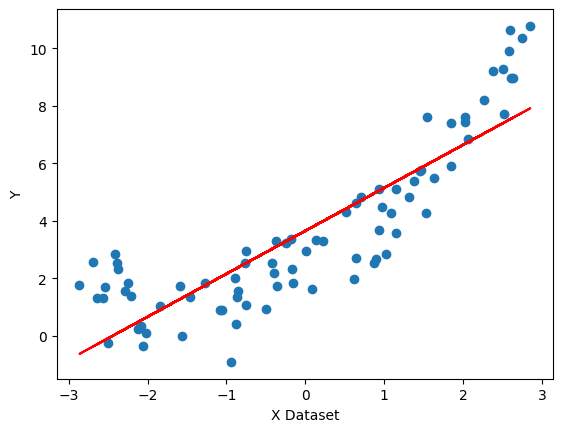

In [27]:
## Lets visualize this model
plt.plot(X_train,regression_1.predict(X_train),color='r')
plt.scatter(X_train,y_train)
plt.xlabel("X Dataset")
plt.ylabel("Y")

In [28]:
#LEts apply polynomial transformation
from sklearn.preprocessing import PolynomialFeatures

In [29]:
poly=PolynomialFeatures(degree=2,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [30]:
X_train_poly

array([[ 1.00000000e+00,  1.02392235e+00,  1.04841698e+00],
       [ 1.00000000e+00, -1.08028498e+00,  1.16701564e+00],
       [ 1.00000000e+00, -1.26624964e+00,  1.60338816e+00],
       [ 1.00000000e+00,  5.11121788e-01,  2.61245483e-01],
       [ 1.00000000e+00, -3.56662824e-01,  1.27208370e-01],
       [ 1.00000000e+00,  2.37252337e+00,  5.62886712e+00],
       [ 1.00000000e+00,  8.26909327e-02,  6.83779036e-03],
       [ 1.00000000e+00,  1.08698189e+00,  1.18152963e+00],
       [ 1.00000000e+00, -1.05091169e+00,  1.10441538e+00],
       [ 1.00000000e+00, -4.00436935e-01,  1.60349739e-01],
       [ 1.00000000e+00, -7.65756582e-01,  5.86383143e-01],
       [ 1.00000000e+00,  9.27707487e-01,  8.60641182e-01],
       [ 1.00000000e+00, -1.69087828e-01,  2.85906936e-02],
       [ 1.00000000e+00,  2.85059054e+00,  8.12586641e+00],
       [ 1.00000000e+00, -2.50507202e+00,  6.27538584e+00],
       [ 1.00000000e+00, -8.51165556e-01,  7.24482803e-01],
       [ 1.00000000e+00, -2.08030678e+00

In [31]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.8738633920128052


In [32]:
print(regression.coef_)

[[0.         1.51255627 0.46109999]]


In [33]:
print(regression.intercept_)

[2.35910952]


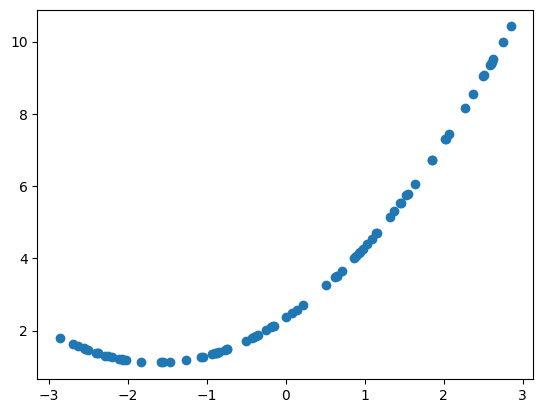

In [35]:
plt.scatter(X_train,regression.predict(X_train_poly))

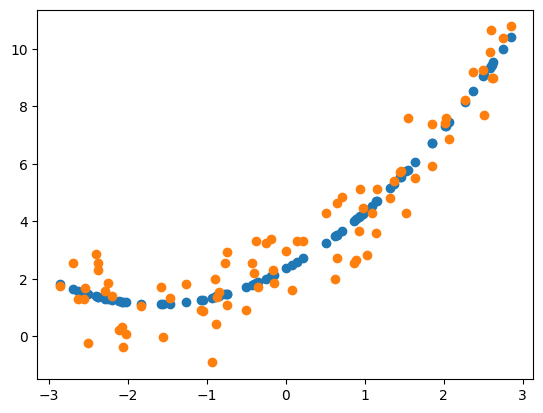

In [36]:
plt.scatter(X_train,regression.predict(X_train_poly))
plt.scatter(X_train,y_train)

In [37]:
poly=PolynomialFeatures(degree=3,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [38]:
X_train_poly

array([[ 1.00000000e+00,  1.02392235e+00,  1.04841698e+00,
         1.07349758e+00],
       [ 1.00000000e+00, -1.08028498e+00,  1.16701564e+00,
        -1.26070948e+00],
       [ 1.00000000e+00, -1.26624964e+00,  1.60338816e+00,
        -2.03028969e+00],
       [ 1.00000000e+00,  5.11121788e-01,  2.61245483e-01,
         1.33528258e-01],
       [ 1.00000000e+00, -3.56662824e-01,  1.27208370e-01,
        -4.53704964e-02],
       [ 1.00000000e+00,  2.37252337e+00,  5.62886712e+00,
         1.33546188e+01],
       [ 1.00000000e+00,  8.26909327e-02,  6.83779036e-03,
         5.65423262e-04],
       [ 1.00000000e+00,  1.08698189e+00,  1.18152963e+00,
         1.28430130e+00],
       [ 1.00000000e+00, -1.05091169e+00,  1.10441538e+00,
        -1.16064304e+00],
       [ 1.00000000e+00, -4.00436935e-01,  1.60349739e-01,
        -6.42099581e-02],
       [ 1.00000000e+00, -7.65756582e-01,  5.86383143e-01,
        -4.49026751e-01],
       [ 1.00000000e+00,  9.27707487e-01,  8.60641182e-01,
      

In [39]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.8724190701782045


In [40]:
#3 Prediction of new data set
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

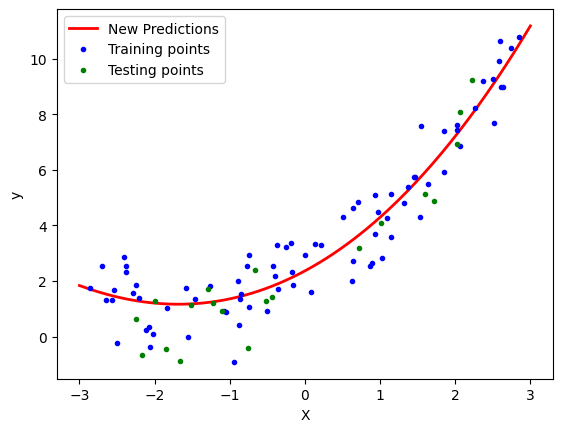

In [42]:
y_new = regression.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label="New Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()